In [1]:
import sys
sys.path.insert(1, '../../../Utils/')
from unet_utils import *
sys.path.insert(1, '../../../Utils/')
from metrics import *
from pathlib import Path
import cv2
import imutils
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
from sklearn.model_selection import KFold
import matplotlib.pyplot as plt

In [2]:
tf.config.list_physical_devices('GPU')

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

# Dataset 

In [3]:
path=Path('../../../../Datasets/Processed/dataset/')
path_tot=path/'train_def'
path_test=path/'test_def'
path_gt=path/'GT_TE'
path_models=Path('Harun/TE')

In [4]:
dim=(256,256)
x,y=load_imgs(path_tot,dim,path_gt)

In [5]:
kfold = KFold(n_splits=10, shuffle=True, random_state=42)

# Model

In [ ]:
model= build_unet(input_shape=(256,256,1))

In [7]:
callbacks = [
    EarlyStopping(patience=15),
    ReduceLROnPlateau(factor=0.05, patience=5)]

In [ ]:
fold_no = 1
for train, test in kfold.split(x):
    x_train, y_train = x[train], y[train]
    x_test, y_test = x[test], y[test]
    
    x_train, mean, std = std_norm(x_train)
    x_test = std_norm_test(x_test, mean, std)
    
    x_train, y_train = data_augmentation(x_train, y_train)
    x_train, y_train = shuffle(x_train, y_train, random_state=13)
    
    x_train = x_train.astype("float32") 
    y_train = y_train.astype("float32")/255  

    x_test = x_test.astype("float32") 
    y_test = y_test.astype("float32")/255  
    
    train_gen = DataGenerator(x_train, y_train, 16)
    model= build_unet(input_shape=(256,256,1))
    model.compile(optimizer=Adam(learning_rate=0.0001), loss=my_loss_fn, metrics=[jaccard_index])
    
    print(f'Training for fold {fold_no} ...')
    history = model.fit(train_gen,batch_size=16, epochs=200, callbacks=callbacks, validation_data=(x_test, y_test))
    model.save(path_models/('fold'+str(fold_no)))    
    fold_no = fold_no + 1

# Metrics

In [6]:
x_test, y_test = load_imgs(path_test,dim,path_gt)

In [7]:
_, mean, std = std_norm(x)
x_test = std_norm_test(x_test, mean, std) 

In [8]:
x_test = x_test.astype("float32") 
y_test = y_test.astype("float32")/255 

In [8]:
def summary_metrics(y_test,predictions,thresh=0.5):
    a,p,r,s,j,d=0.,0.,0.,0.,0.,0.
    n=len(predictions)
    for i in range(n):
        preds= (predictions[i][:,:,0]>=thresh).astype('uint8')
        gt= y_test[i].astype('uint8')
        metricas=metrics(gt,preds)
        a+=metricas['accuracy']
        p+=metricas['precision']
        r+=metricas['recall']
        s+=metricas['specificity']
        j+=metricas['jaccard']
        d+=metricas['dice']
    return {'accuracy': a/n,
            'precision': p/n,
            'recall': r/n,
            'specificity': s/n,
            'jaccard':j/n,
            'dice': d/n}

In [9]:
m1=[]
for fold_no in range(1,11): 
    model= tf.keras.models.load_model(path_models/'fold{}'.format(fold_no),custom_objects={'jaccard_index':jaccard_index, 'my_loss_fn':my_loss_fn})
    predictions = model.predict(x_test)
    m1.append(summary_metrics(y_test,predictions, 0.5))

In [10]:
accuracy=[el['accuracy'] for el in m1]
precision=[el['precision'] for el in m1]
recall=[el['recall'] for el in m1]
specificity=[el['specificity'] for el in m1]
jaccard=[el['jaccard'] for el in m1]
dice=[el['dice'] for el in m1]

In [11]:
np.mean(accuracy), np.std(accuracy)

(0.956975970986257, 0.0017498726770872285)

In [12]:
np.mean(precision), np.std(precision)

(0.7909096012183184, 0.009936970940771627)

In [13]:
np.mean(recall), np.std(recall)

(0.8438483924712289, 0.035164168274792164)

In [14]:
np.mean(specificity), np.std(specificity)

(0.9718529778720246, 0.002925786541765161)

In [15]:
np.mean(jaccard), np.std(jaccard)

(0.6825210220097049, 0.020275209968325048)

In [16]:
np.mean(dice), np.std(dice)

(0.801099930037821, 0.0198904966702916)

In [18]:
for m in m1:
    print('accuracy: ' +str(m['accuracy']))
    print('precision: ' +str(m['precision']))
    print('recall: ' +str(m['recall']))
    print('specificity: ' +str(m['specificity']))
    print('dice: ' +str(m['dice']))
    print('jaccard: ' +str(m['jaccard']))
    print('--------------------------')

accuracy: 0.9555261270652258
precision: 0.8151550380967091
recall: 0.788020177444169
specificity: 0.9774754550252542
dice: 0.7743424737739746
jaccard: 0.655181066399757
--------------------------
accuracy: 0.9562031251129334
precision: 0.7877756756050265
recall: 0.8574987604744994
specificity: 0.9700609278086322
dice: 0.8025137069856032
jaccard: 0.6840048193754135
--------------------------
accuracy: 0.9586983005983764
precision: 0.783946614666357
recall: 0.8834628518715157
specificity: 0.9689874186492073
dice: 0.8239791843142189
jaccard: 0.705987542655883
--------------------------
accuracy: 0.9599033250000202
precision: 0.7868075020784037
recall: 0.8785226762878137
specificity: 0.970406431305841
dice: 0.824817902600086
jaccard: 0.707419228994267
--------------------------
accuracy: 0.9572993319161617
precision: 0.7899570346116634
recall: 0.8483240320313433
specificity: 0.9714286926494174
dice: 0.8037394640144845
jaccard: 0.6839443588828713
--------------------------
accuracy: 0.95786

In [31]:
model= tf.keras.models.load_model(path_models/'fold3',custom_objects={'jaccard_index':jaccard_index, 'my_loss_fn':my_loss_fn})
predictions = model.predict(x_test)
preds= (predictions[0][:,:,0]>=0.5).astype('uint8')

In [32]:
path_test=path/'test_def'
files=[path_test/f for f in os.listdir(path_test)]
img=cv2.imread(str(files[0]))

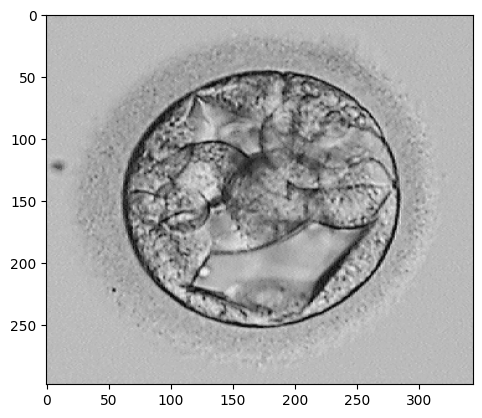

In [33]:
plt.imshow(img)

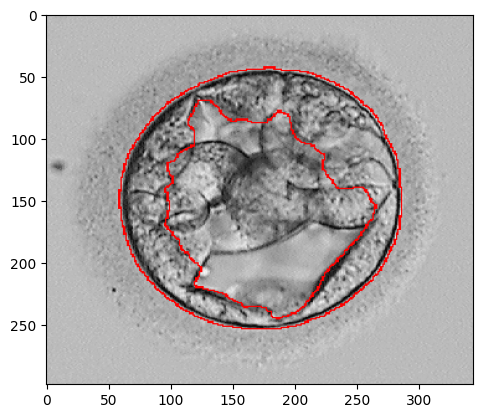

In [37]:
img=cv2.imread(str(files[0]))
TE=255*preds
TE=cv2.dilate(TE, np.ones((5,5)))-TE
TE=cv2.resize(TE,(344, 298))
img[TE==255]=0
img[:,:,0][TE==255]=255
plt.imshow(img)

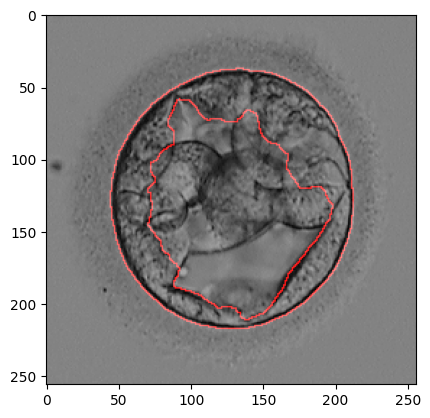

In [31]:
plt.imshow(cv2.addWeighted(cv2.resize(img,(256,256)), 0.7, TE, 1, 0.0))

In [ ]:
plt.imshow(cv2.addWeighted(img, 0.7, TE, 1, 0.0))